<a href="https://colab.research.google.com/github/joandavid-cicese/taller_Foro_Seguridad/blob/main/Practica2_foro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Aprendizaje no supervisado: Detección de anomalías

## Paso 1: Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
import os
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🔒 Taller: IA Defensiva para Ciberseguridad")
print("📊 Ambiente configurado correctamente")
print("-" * 50)

🔒 Taller: IA Defensiva para Ciberseguridad
📊 Ambiente configurado correctamente
--------------------------------------------------


In [2]:
print("\n2️⃣ Práctica 2: APRENDIZAJE NO SUPERVISADO - Detección de Anomalías")
print("-" * 50)


2️⃣ Práctica 2: APRENDIZAJE NO SUPERVISADO - Detección de Anomalías
--------------------------------------------------


## Paso 2: Importación del dataset

https://www.kaggle.com/datasets/hassan06/nslkdd

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassan06/nslkdd")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nslkdd' dataset.
Path to dataset files: /kaggle/input/nslkdd


In [4]:
# Nombres de las columnas del dataset NSL-KDD
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

try:
    file_path = os.path.join(path, "KDDTrain+.txt") # pasamos la ruta + el nombre del dataset
    df_traffic = pd.read_csv(file_path, header=None, names=column_names) # lo convertimos a un DataFrame de pandas para poder trabajar
    print("Dataset cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el dataset: {e}")
    print("Por favor, verifique el enlace o descargue el archivo manualmente.")

Dataset cargado exitosamente.


In [5]:
print(df_traffic.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

## Paso 3: Feature Engineering

### Transformación de características categóricas

In [8]:
df_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [9]:
# Identificar columnas categóricas
categorical_cols = ['protocol_type', 'service', 'flag']

# Aplicar One-Hot Encoding
df_categorical = pd.get_dummies(df_traffic[categorical_cols])

# Unir las nuevas columnas al dataframe original y eliminar las originales
df_numeric = pd.concat([df_traffic.drop(categorical_cols, axis=1), df_categorical], axis=1)

# La columna 'label' también es categórica, pero la mantendremos por ahora para la evaluación final.
# La columna 'difficulty' no es necesaria para este análisis.
df_numeric = df_numeric.drop(['label', 'difficulty'], axis=1)

### Normalización

In [10]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

## Paso 4: Aplicar algoritmos (KMEANS and IsolationForest)

### Buscar número de clusters

1h en ejecutar (**NO EJECUTAR EN LA PRÁCTICA**)

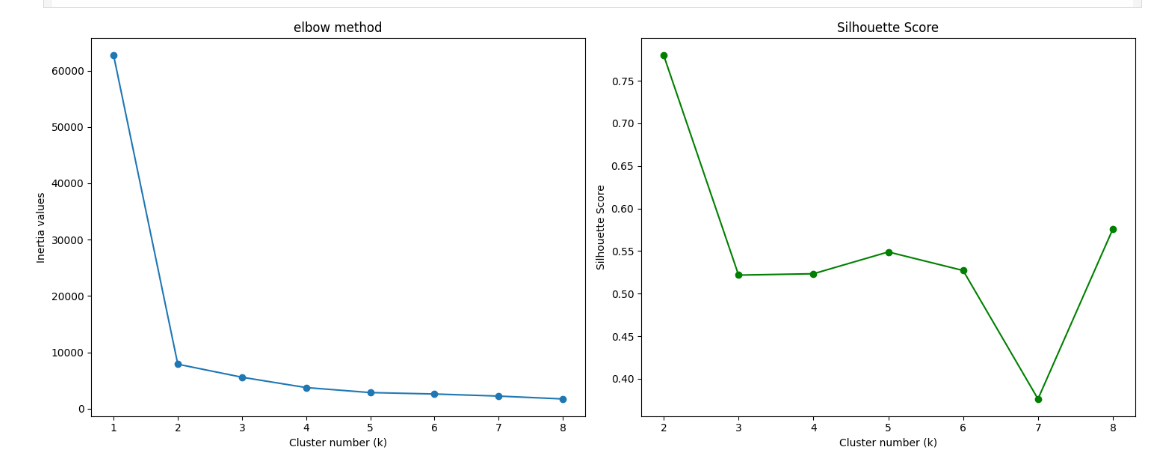

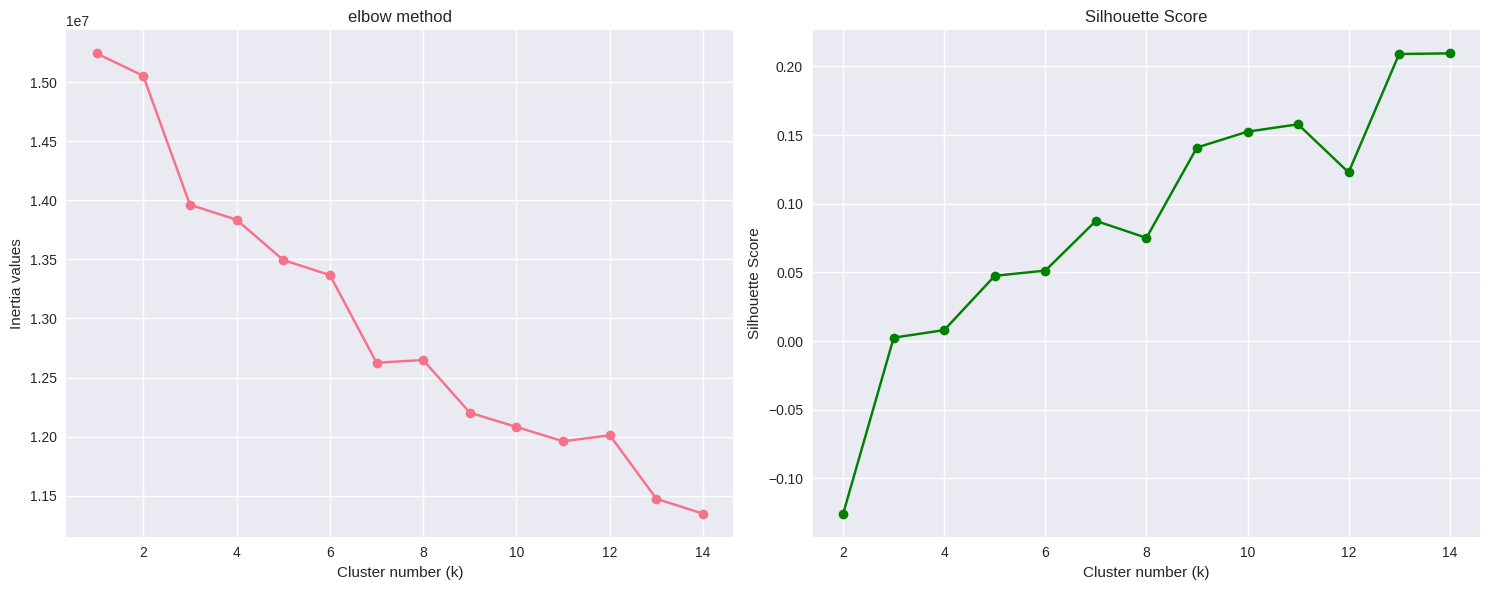

In [ ]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K = range(1, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

    # Calcular Silhouette Score para k >= 2
    if k > 1:
        score = silhouette_score(df_scaled, kmeans.labels_)
        silhouette_scores.append(score)

# Crear la figura con subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico del codo
axes[0].plot(K, inertia, marker='o')
axes[0].set_xlabel('Cluster number (k)')
axes[0].set_ylabel('Inertia values')
axes[0].set_title('elbow method')

# Gráfico del Silhouette Score para k >= 2
axes[1].plot(range(2, 15), silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Cluster number (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

# Ajustar el espaciado entre los subplots
plt.tight_layout()

# Mostrar la gráfica
plt.show()

A primera vista esas gráficas pueden parecer confusas o "raras", pero en realidad nos están contando una historia muy interesante y común sobre los datos de ciberseguridad.

Gráfica del Método del Codo (Inertia):
- Qué Muestra: La inercia mide qué tan compactos son tus clusters. En términos simples, es la suma de las distancias al cuadrado de cada punto de datos a su centroide más cercano. Un valor más bajo es mejor.
- Nuestra gráfica: La inercia siempre disminuirá a medida que aumentamos el número de clusters (k). Esto es lógico: si tenemos más clusters, cada punto estará, en promedio, más cerca de algún centroide.

¿Dónde está el "Codo"? El "codo" es el punto donde la gráfica empieza a aplanarse, es decir, el punto de rendimientos decrecientes. Añadir más clusters ya no mejora la compacidad de forma significativa. En nuestra gráfica, aunque no es un codo súper pronunciado, se puede ver que la caída más drástica ocurre hasta k=7 u 8. A partir de ahí, la pendiente se suaviza.

Conclusión del Codo: Este método sugiere que un número de clusters alrededor de 7 u 8 es un buen punto de partida.

Gráfica del Coeficiente de Silueta (Silhouette Score):
- Qué Muestra: El score de silueta mide qué tan bien definido está un cluster. No solo considera qué tan juntos están los puntos dentro de un cluster (cohesión), sino también qué tan separados están de los puntos de otros clusters (separación). El score va de -1 a 1, donde un valor más alto es mejor.
- Nuestra gráfica: Nos dice que para k=2, el score es negativo, lo cual es muy malo. Significa que los clusters se superponen y los puntos podrían estar en el cluster equivocado. El score más alto se alcanza en k=13 y k=14.

Conclusión de la Silueta: Este método sugiere que el mejor número de clusters es 13 o 14

¿Por Qué la Contradicción? 🤔

Esta es la clave. El método del codo y el de la silueta miden cosas diferentes, y en un dataset como NSL-KDD, esta diferencia es crucial.

Naturaleza de los Datos: El tráfico de red "normal" tiende a formar uno o varios clusters grandes y densos. En cambio, los ataques son a menudo anomalías: son diferentes del tráfico normal y también son diferentes entre sí.

Lo que ve K-Means:

Cuando usamos un k alto (como 13 o 14), el algoritmo K-Means puede estar dividiendo el gran cluster de tráfico "normal" en muchos sub-clusters más pequeños y muy compactos. Esto hace que el score de silueta aumente, porque estos pequeños sub-clusters de tráfico normal están muy bien definidos y separados entre sí.

El problema es que al hacer esto, algunos ataques podrían terminar formando su propio pequeño "cluster" y el modelo podría pensar que son simplemente otro tipo de comportamiento "normal".

Para nuestro objetivo, que es la detección de anomalías, generalmente es mejor definir clusters más amplios que representen el comportamiento "normal".

Comencemos con un valor de k=8. Este valor representa un buen equilibrio donde los clusters son razonablemente compactos sin dividirse en exceso. Usaremos este número para entrenar nuestro modelo K-Means y luego identificaremos los puntos de datos (conexiones) que están más alejados de los centros de estos 8 clusters. Esos serán nuestros candidatos a anomalías.

### Entrenamiento KMeans

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

In [11]:
# Entrenar K-Means con el k óptimo (ej. k=8)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10) # optimización que ejecuta el algoritmo 10 veces y se queda con el mejor resultado para asegurar un buen agrupamiento
clusters = kmeans.fit_predict(df_scaled)

# Calcular la distancia de cada punto a su centroide
distances = kmeans.transform(df_scaled)
min_distances = distances.min(axis=1) # De esas 8 distancias, nos quedamos solo con la más pequeña, que es la distancia al centroide de su propio cluster.

# Definir un umbral para las anomalías (ej. el percentil 95 de las distancias)
threshold = np.percentile(min_distances, 95) #  5% de los datos que están más alejados de cualquier centro de cluster
anomalies_kmeans = np.where(min_distances > threshold)[0] # y por lo tanto, se etiquetan como anomalías

print(f"Número de anomalías detectadas por K-Means: {len(anomalies_kmeans)}")

Número de anomalías detectadas por K-Means: 6299


### Entrenamiento IsolationForest

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

In [ ]:
from sklearn.ensemble import IsolationForest

# Entrenar el modelo
iso_forest = IsolationForest(contamination='auto', random_state=42)
anomalies_if = iso_forest.fit_predict(df_scaled)

# El resultado es -1 para anomalías y 1 para inliers (normales)
num_anomalies_if = np.sum(anomalies_if == -1)
print(f"Número de anomalías detectadas por Isolation Forest: {num_anomalies_if}")

Número de anomalías detectadas por Isolation Forest: 30


## Paso 5: Análisis de los resultados del entrenamiento

Se puede observar la gran diferencia en el número de anomalías (6,299 de K-Means vs. 30 de Isolation Forest) se debe a que ambos algoritmos tienen una definición fundamentalmente distinta de lo que es una "anomalía".

K-Means: Anomalías por Distancia 📏

1. K-Means no es un algoritmo de detección de anomalías, es un algoritmo de clustering. Nosotros lo adaptamos para inferir anomalías basándonos en una suposición: que las anomalías serán los puntos más alejados de cualquier centro de un cluster "normal".

2. Nuestro Umbral es la Clave: Al establecer threshold = np.percentile(min_distances, 95), le dimos una orden explícita al modelo: "Marca como anomalía el 5% de los datos que estén más lejos de cualquier centroide".

3. Cálculo: El dataset de entrenamiento (KDDTrain+) tiene 125,973 registros. El 5% de 125,973 es aproximadamente 6,298.65. El resultado que obtuvimos (6,299) es exactamente lo que pedimos.

4. El Problema: Esta aproximación asume que el porcentaje de ataques en el dataset es del 5%, lo cual puede ser o no ser cierto. La "detección" está completamente definida por el umbral que fijamos.

Isolation Forest: Anomalías por Aislamiento 🌳

Isolation Forest sí está diseñado específicamente para la detección de anomalías. No se basa en distancias, sino en la facilidad con la que un punto de datos puede ser "aislado" del resto.

1. Cómo Funciona: Imagina que construyes muchos árboles de decisión aleatorios. Una anomalía es un punto atípico y diferente, por lo que será muy fácil de separar del resto de los datos; necesitará pocas "divisiones" en el árbol para quedar aislada. Un punto normal, al estar en una región densa con muchos otros puntos similares, requerirá muchas más divisiones para ser aislado.

2. El Parámetro contamination: Al usar 'auto', el algoritmo utiliza un método introducido en publicaciones más recientes para estimar el porcentaje de anomalías directamente de los datos, en lugar de que nosotros lo pongamos. El modelo ha estimado que solo una fracción muy pequeña de los datos (los 30 puntos más fáciles de aislar) son verdaderamente anómalos.

**¿Cuál es Mejor y Qué Hacemos Ahora?**

El Siguiente Paso Crucial: La Verificación con Etiquetas, usar las etiquetas reales para evaluar el rendimiento.

## Paso 6: Evaluación de los modelos

In [ ]:
# Crear una etiqueta binaria (1 para ataque, 0 para normal)
df_traffic['is_attack'] = df_traffic['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [ ]:
from sklearn.metrics import classification_report

# Crear un array de predicciones para K-Means
predictions_kmeans = np.zeros_like(df_traffic['is_attack'])
predictions_kmeans[anomalies_kmeans] = 1

print("Reporte de Clasificación para K-Means:")
print(classification_report(df_traffic['is_attack'], predictions_kmeans))

# Convertir las predicciones de Isolation Forest a nuestro formato (1 para anomalía, 0 para normal)
predictions_if = [1 if x == -1 else 0 for x in anomalies_if]

print("\nReporte de Clasificación para Isolation Forest:")
print(classification_report(df_traffic['is_attack'], predictions_if))

Reporte de Clasificación para K-Means:
              precision    recall  f1-score   support

           0       0.55      0.98      0.70     67343
           1       0.77      0.08      0.15     58630

    accuracy                           0.56    125973
   macro avg       0.66      0.53      0.43    125973
weighted avg       0.65      0.56      0.45    125973


Reporte de Clasificación para Isolation Forest:
              precision    recall  f1-score   support

           0       0.53      1.00      0.70     67343
           1       0.03      0.00      0.00     58630

    accuracy                           0.53    125973
   macro avg       0.28      0.50      0.35    125973
weighted avg       0.30      0.53      0.37    125973



**Análisis de K-Means (k=8, umbral del 5%)**
1. Clase 1 (Ataques):

    precision: 0.77 -> Significa que cuando K-Means dice que algo es un ataque, acierta el 77% de las veces.
    
    recall: 0.08 -> Este es el problema. ¡Solo encontró el 8% del total de ataques reales!

Podríamos decir que el modelo KMeans fue como un guardia de seguridad muy cauteloso. No dio muchas falsas alarmas, pero se le pasaron por alto el 92% de los intrusos. En ciberseguridad, esto es inaceptable. Un bajo recall para los ataques significa que el sistema es vulnerable.

**Análisis de Isolation Forest (contamination='auto')**

2. Clase 1 (Ataques):

    precision: 0.03 -> Esto es muy malo. Cuando marcó algo como ataque, solo acertó el 3% de las veces. Las 30 "anomalías" que encontró eran, en su mayoría, tráfico normal pero atípico.
    
    recall: 0.00 -> Este es el resultado más crítico. No encontró prácticamente ningún ataque real 🤯

 Con la configuración automática, el modelo fue un fracaso total para esta tarea. El método 'auto' fue extremadamente conservador y asumió que las anomalías eran ultra raras y muy obvias. Claramente, los ataques en el dataset NSL-KDD no cumplen con esa suposición; pueden ser más sutiles o numerosos.

**¿Qué Salió Mal y Cómo lo Arreglamos?**

El problema principal no son los algoritmos, sino nuestra configuración inicial. En el aprendizaje no supervisado, guiar al modelo es clave.

El umbral de K-Means fue arbitrario: Asumimos que el 5% de los datos más "lejanos" eran ataques, pero la realidad es diferente.

El 'auto' de Isolation Forest no funcionó: La heurística automática del algoritmo falló para este dataset. Es una buena primera aproximación, pero estos resultados nos obligan a intervenir.

## Paso 7: Fine-tuning IsolationForest

La gran ventaja de Isolation Forest es que podemos decirle explícitamente qué proporción de los datos esperamos que sean anomalías. Este es el hiperparámetro contamination.

Sabemos (aunque en un caso real no lo sabríamos) que en este dataset, los ataques representan aproximadamente el 46% del total (58630 / 125973). Fijar la contaminación en 0.46 sería hacer trampa, pero podemos usar una estimación más realista.

Vamos a re-entrenar Isolation Forest, pero esta vez le diremos que espere un 10% de anomalías. Este es un valor mucho más razonable para un escenario de tráfico mixto

In [ ]:
# Re-entrenar Isolation Forest con una contaminación del 10%
iso_forest_tuned = IsolationForest(contamination=0.1, random_state=42)

# El resto del código es igual
anomalies_if_tuned = iso_forest_tuned.fit_predict(df_scaled)
predictions_if_tuned = [1 if x == -1 else 0 for x in anomalies_if_tuned]

print("\nReporte de Clasificación para Isolation Forest (Contamination=0.1):")
print(classification_report(df_traffic['is_attack'], predictions_if_tuned))


Reporte de Clasificación para Isolation Forest (Contamination=0.1):
              precision    recall  f1-score   support

           0       0.56      0.95      0.71     67343
           1       0.72      0.15      0.25     58630

    accuracy                           0.58    125973
   macro avg       0.64      0.55      0.48    125973
weighted avg       0.63      0.58      0.50    125973



Al forzar al modelo a considerar que el 10% de los datos son anómalos, hemos mejorado significativamente su rendimiento para la tarea de detectar ataques.

Clase 1 (Ataques):

- precision: 0.72 -> Cuando el modelo levanta una bandera roja, acierta el 72% de las veces.

- recall: 0.15 -> ¡Hemos duplicado la capacidad de detección! Ahora el modelo encuentra el 15% de todos los ataques reales, comparado con el pobre 8% que lograba K-Means.

- f1-score: 0.25 -> Este es el indicador más importante del progreso. Aunque 0.25 todavía es bajo, es mucho mejor que el 0.15 de K-Means. Nos dice que este modelo tiene un balance superior entre precisión y recall.

## ¿Cuál es el Siguiente Paso? 🤔